# Combined Diamond + Eikosany Optimisation

Finds the `shiftVector` that maximises the number of Penrose tiling nodes
that are members of the **Hexadic Diamond** or the **Eikosany**.

Unlike the proxy optimisations in `penrose5D.ipynb` (which test only the
31 / 20 canonical lattice vectors), this notebook regenerates `selPoints`
from the full 7⁵ integer grid for every trial `sv` — exactly as the main
pipeline does — and applies the same ratio-based Diamond membership test,
including paths with coordinates outside {−1, 0, 1}.

The Diamond ratio check uses log-arithmetic instead of SymPy for speed:
it computes `(pt5 · log rᵢ) mod log 2` and compares against precomputed
fingerprints of the 31 Diamond intervals.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
from scipy.spatial import ConvexHull, Delaunay
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from sympy import symbols, Integer, Rational

import json
    
from ji_tiling import (
    basis2D, in_hull,
    setup_a4_projection, make_acceptance_hull, make_int_grid,
    DIAMOND_RATIOS,
)

## Projection setup

Identical to `penrose5D.ipynb`: cyclic permutation matrix → eigenvectors →
2D projection `p` (E∥) and 3D projection `y` (E⊥ + [1,1,1,1,1]).

In [2]:
eigenVectors, p, y = setup_a4_projection()

2D projection plane (E∥):
-->5D basis vectors are rotated in 2D plane by (2.0π)/5
3D acceptance-window space (E⊥ + uniform):
-->5D basis vectors are rotated in 2D plane by (3.9999999999999996π)/5


## Convex hull (acceptance window)

In [3]:
hull, hull_del = make_acceptance_hull(y)
print(f'Hull vertices: {len(hull.vertices)}')

Hull vertices: 22


## Diamond ratios and starting shift vector

In [4]:
from sympy import Rational
diamond_ratios = set(Rational(n, d) for n, d in DIAMOND_RATIOS)
print(f'Diamond ratios loaded from DIAMOND_RATIOS: {len(diamond_ratios)}')

# Starting guess 
# shiftVector = np.array([-0.36844, -0.491094, 0.315972, 0.430247, 0.113314])
shiftVector = np.array([4/5, -1/5, -1/5, -1/5, -1/5])

print(f'Starting shiftVector: {np.round(shiftVector, 6)}')

Diamond ratios loaded from DIAMOND_RATIOS: 29
Starting shiftVector: [ 0.8 -0.2 -0.2 -0.2 -0.2]


In [5]:
# Get the extended Eikosany set from 
with open('../Data/eikosany_diamond.json', 'r') as file:
    eikos_ALL = json.load(file)

## Optimisation

In [6]:
from itertools import combinations

rI_float = np.array([3., 5., 7., 9., 11.])
log2     = np.log(2.0)
log_rI   = np.log(rI_float)

def _norm(x):
    """Normalise a positive ratio into [1, 2)."""
    while x >= 2.0: x /= 2.0
    while x < 1.0:  x *= 2.0
    return x

# --- Precompute Diamond real values in [1, 2) ---
diamond_float = np.array(sorted(set(_norm(float(r)) for r in diamond_ratios)))

# --- Precompute Eikosany real values in [1, 2) ---
# Generators {1,3,5,7,9,11}; choose 3.  "1" contributes no factor,
# so products with "1" are 2-element products of {3,5,7,9,11}.
# Encoded as {0,1}^5 vectors with sum 2 or 3 (indices into rI_float).
# eiko_float = sorted(set(
#     _norm(np.prod(rI_float[list(idx)]))
#     for r in (2, 3)
#     for idx in combinations(range(5), r)
# ))
# eiko_float = np.array(eiko_float)

eiko_float = np.sort(np.array(eikos_ALL['num'])/np.array(eikos_ALL['den']))
mask = np.isin(eiko_float,diamond_float)
eiko_float = eiko_float[~mask]

# --- Combined log-normalised target fingerprints ---
target_log_norm = np.unique(
    np.concatenate([np.log(diamond_float), np.log(eiko_float)]) % log2
)
# target_log_norm = np.log(diamond_float) % log2  # to optimize based on just hexadic diamond

print(f'Diamond target values  : {len(diamond_float)}')
print(f'Eikosany target values : {len(eiko_float)}')
print(f'Combined unique targets: {len(target_log_norm)}')

# --- Precompute integer grid (d=3)
# count_combined() closes over int_grid by reference, so this takes effect immediately.
int_grid = make_int_grid(3)
print(f'Integer grid (make_int_grid): {int_grid.shape}')

def count_combined(sv_free):
    """Count hull points whose normalised ratio matches a Diamond or Eikosany value."""
    sv        = np.append(sv_free, -sv_free.sum())
    shifted   = int_grid + sv
    projected = (y @ shifted.T).T
    sel_int   = int_grid[in_hull(projected, hull_del)]

    if len(sel_int) == 0:
        return 0

    # Log-ratio for every selected point, normalised to [0, log2)
    log_norm = (sel_int @ log_rI) % log2                     # (N,)

    # Vectorised nearest-target check
    diffs   = np.abs(log_norm[:, None] - target_log_norm[None, :])  # (N, T)
    return int((diffs.min(axis=1) < 1e-7).sum())


# --- Baseline ---
baseline = count_combined(shiftVector[:4])
print(f'\nBaseline combined count: {baseline}')

# --- Global optimisation ---
result = differential_evolution(
    lambda sv: -count_combined(sv),
    bounds   = [(-0.8, 0.8)] * 4,
    seed     = 42,
    maxiter  = 300,
    popsize  = 15,
    tol      = 0,
    polish   = True,
    disp     = False,
    x0       = shiftVector[:4],
)

sv_opt = np.append(result.x, -result.x.sum())
best   = -int(result.fun)

print(f'\nOptimal shiftVector : {np.round(sv_opt, 6)}')
print(f'Combined nodes found: {best}  (baseline: {baseline})')
print(f'Improvement         : {best - baseline}')


Diamond target values  : 29
Eikosany target values : 104
Combined unique targets: 115
Integer grid (make_int_grid): (16807, 5)

Baseline combined count: 11

Optimal shiftVector : [-0.600833  0.742993 -0.746118  0.123493  0.480464]
Combined nodes found: 33  (baseline: 11)
Improvement         : 22


## Fixed shiftVector: scalar ratio multiplier

The shiftVector `ω₁ = (4/5, −1/5, −1/5, −1/5, −1/5)` is the first fundamental weight of A₄ and a
minuscule weight — it is the canonical geometric choice for the Penrose cut-and-project construction.

With the shiftVector fixed, the only remaining degree of freedom is a single scalar multiplier `r`
applied uniformly to all tiling-point ratios.  A tiling point with 5D coordinates `pt` has ratio
`R = 3^a·5^b·7^c·9^d·11^e`; after multiplication its octave-normalised log-fingerprint becomes
`(log(r) + pt·log_rI) mod log2`.

Because the objective is integer-valued and piecewise-constant, the optimal `r` must occur at one
of the finite candidate shifts `log_r = (t_j − log_norm_i) mod log2` — one per (tiling point,
target) pair.  Evaluating all candidates is exact and requires no iteration.

In [7]:
# --- Fixed shiftVector (minuscule weight ω₁ of A₄) ---
sv_fixed = np.array([4/5, -1/5, -1/5, -1/5, -1/5])
# sv_fixed = np.array([0.25, 0.25, 0.25, 0.25, 0.25])
# sv_fixed = (9/10, -1/10, -1/10, -1/10, -1/10)

# sv_fixed = np.array([-0.600833,  0.742993, -0.746118,  0.123493,  0.480464])

shifted_fixed   = int_grid + sv_fixed
projected_fixed = (y @ shifted_fixed.T).T
sel_int_fixed   = int_grid[in_hull(projected_fixed, hull_del)]

log_norm_fixed = (sel_int_fixed @ log_rI) % log2   # (N,) fingerprints

print(f'Fixed shiftVector : {sv_fixed}')
print(f'Selected tiling nodes: {len(sel_int_fixed)}')
print(f'Baseline score (r=1) : {(np.min(np.abs(log_norm_fixed[:, None] - target_log_norm[None, :]), axis=1) < 1e-7).sum()}')

Fixed shiftVector : [ 0.8 -0.2 -0.2 -0.2 -0.2]
Selected tiling nodes: 258
Baseline score (r=1) : 11


In [8]:
def score_ratio(log_r):
    """Count tiling nodes whose ratio × r lands in Diamond or Eikosany."""
    shifted = (log_norm_fixed + log_r) % log2          # (N,)
    diffs   = np.abs(shifted[:, None] - target_log_norm[None, :])
    diffs   = np.minimum(diffs, log2 - diffs)           # wraparound on circle
    return int((diffs.min(axis=1) < 1e-7).sum())

In [9]:
# Analytic enumeration: every candidate optimal shift is (t_j - log_norm_i) % log2
candidates = ((target_log_norm[None, :] - log_norm_fixed[:, None]) % log2).ravel()
candidates = np.unique(np.round(candidates, decimals=10))

scores_cand = np.array([score_ratio(c) for c in candidates])

best_idx   = np.argmax(scores_cand)
best_log_r = candidates[best_idx]
best_score = scores_cand[best_idx]
best_r     = np.exp(best_log_r)

print(f'Candidates evaluated : {len(candidates)}')
print(f'Best score           : {best_score} nodes')
print(f'Best multiplier r    = {best_r:.8f}')
print(f'  (log_r             = {best_log_r:.8f})')
print(f'\nAll shifts achieving best score:')
for c in candidates[scores_cand == best_score]:
    print(f'  r = {np.exp(c):.8f}  (log_r = {c:.8f})')

Candidates evaluated : 2905
Best score           : 62 nodes
Best multiplier r    = 1.14938776
  (log_r             = 0.13922941)

All shifts achieving best score:
  r = 1.14938776  (log_r = 0.13922941)


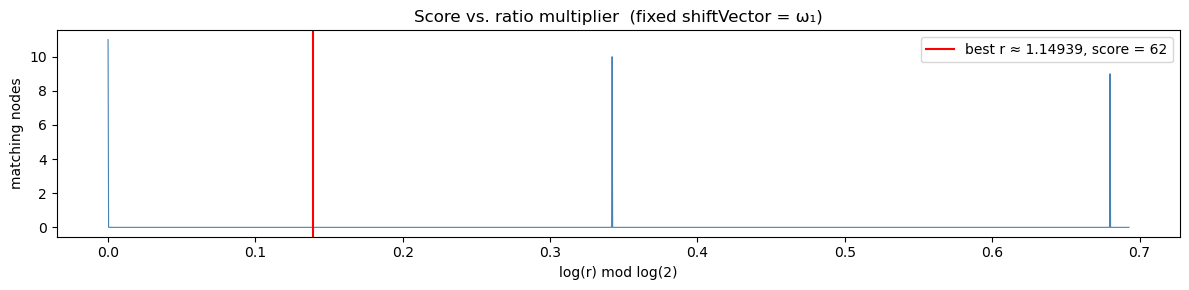

In [10]:
# Score landscape: coarse grid for visualisation
log_r_grid    = np.linspace(0, log2, 2000, endpoint=False)
scores_grid   = np.array([score_ratio(x) for x in log_r_grid])

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(log_r_grid, scores_grid, lw=0.8, color='steelblue')
for c in candidates[scores_cand == best_score]:
    ax.axvline(c, color='red', lw=1.2, alpha=0.7)
ax.axvline(best_log_r, color='red', lw=1.5,
           label=f'best r ≈ {best_r:.5f}, score = {best_score}')
ax.set_xlabel('log(r) mod log(2)')
ax.set_ylabel('matching nodes')
ax.set_title('Score vs. ratio multiplier  (fixed shiftVector = ω₁)')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
from fractions import Fraction

frac     = Fraction(best_r).limit_denominator(100)
log_r_frac = np.log(float(frac)) % log2

print(f'Best multiplier  r  = {best_r:.8f}')
print(f'Nearest rational    = {frac}  = {float(frac):.8f}')
print(f'  deviation         : {abs(float(frac) - best_r):.2e}')
print(f'  score at {frac}  : {score_ratio(log_r_frac)}')

Best multiplier  r  = 1.14938776
Nearest rational    = 100/87  = 1.14942529
  deviation         : 3.75e-05
  score at 100/87  : 0


Matched nodes at r = 1.14938776  (score = 62)
pt                                     orig ratio      ×r ratio       set
---------------------------------------------------------------------------
[ 0  3  2 -1 -2]                         1.406107      1.616162   Eikosany
[ 1  3  2 -1 -2]                         1.054580      1.212121   Eikosany
[-1  3  3 -1 -2]                         1.640458      1.885522   Eikosany
[ 0  3  3 -1 -2]                         1.230343      1.414141   Eikosany
[-1  2  2  0 -2]                         1.687328      1.939394   Eikosany
[-1  3  2  0 -2]                         1.054580      1.212121   Eikosany
[ 0  3  2  0 -2]                         1.581870      1.818182  Diamond
[-2  2  3  0 -2]                         1.968549      1.131313   Eikosany
[-1  2  3  0 -2]                         1.476412      1.696970   Eikosany
[-2  3  3  0 -2]                         1.230343      1.414141   Eikosany
[-1  3  3  0 -2]                         1.845515      1

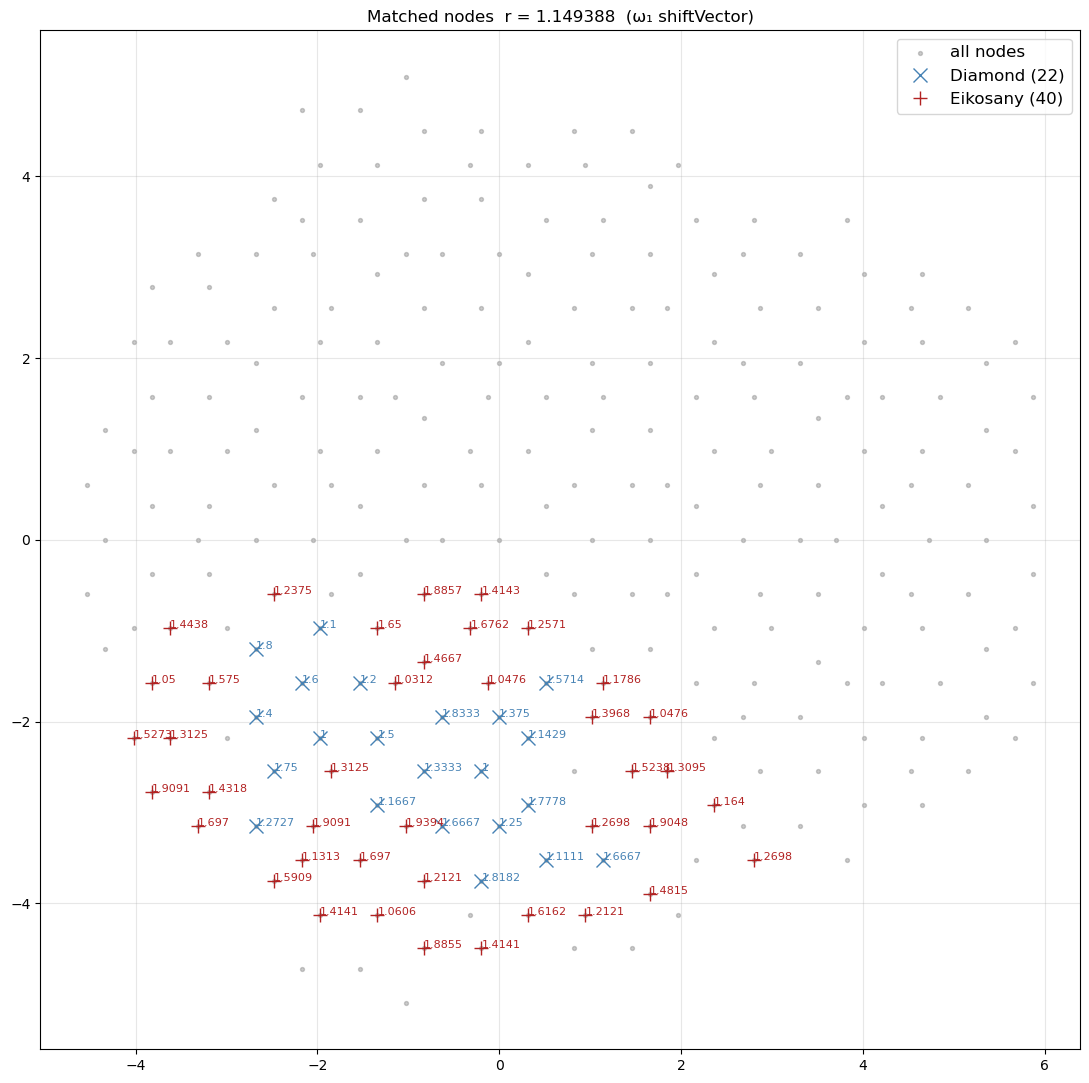

In [12]:
# Display matched nodes at best_log_r
shifted_best = (log_norm_fixed + best_log_r) % log2
diffs_best   = np.abs(shifted_best[:, None] - target_log_norm[None, :])
diffs_best   = np.minimum(diffs_best, log2 - diffs_best)
match_mask   = diffs_best.min(axis=1) < 1e-7

# Separate Diamond vs Eikosany — use same wraparound as score_ratio
diamond_log = np.log(diamond_float) % log2
eiko_log    = np.log(eiko_float)    % log2

def _circ_dists(a, b):
    d = np.abs(a[:, None] - b[None, :])
    return np.minimum(d, log2 - d)

d_dists = _circ_dists(shifted_best[match_mask], diamond_log)
e_dists = _circ_dists(shifted_best[match_mask], eiko_log)
d_idx_m = np.argmin(d_dists, axis=1)
e_idx_m = np.argmin(e_dists, axis=1)
is_d    = d_dists[np.arange(len(d_idx_m)), d_idx_m] < 1e-7
is_e    = e_dists[np.arange(len(e_idx_m)), e_idx_m] < 1e-7

print(f'Matched nodes at r = {best_r:.8f}  (score = {match_mask.sum()})')
print(f'{"pt":35s}  {"orig ratio":>12s}  {"×r ratio":>12s}  {"set":>8s}')
print('-' * 75)
for i, (pt, m_d, m_e) in enumerate(zip(sel_int_fixed[match_mask], is_d, is_e)):
    orig   = np.exp((pt @ log_rI) % log2)
    scaled = diamond_float[d_idx_m[i]] if m_d else eiko_float[e_idx_m[i]]
    member = ('Diamond' if m_d else '') + (' Eikosany' if m_e else '')
    print(f'{str(pt):35s}  {orig:12.6f}  {scaled:12.6f}  {member}')

# Plot
xy_all   = (sel_int_fixed + sv_fixed) @ p.T
xy_match = xy_all[match_mask]
labels_m = [
    f'{diamond_float[d_idx_m[i]]:.5g}' if is_d[i] else f'{eiko_float[e_idx_m[i]]:.5g}'
    for i in range(match_mask.sum())
]

fig, ax = plt.subplots(figsize=(11, 11))
ax.scatter(xy_all[:, 0], xy_all[:, 1], s=8, color='grey', alpha=0.4, label='all nodes')
d_xy = xy_match[is_d]
e_xy = xy_match[is_e]
if len(d_xy):
    ax.plot(d_xy[:, 0], d_xy[:, 1], 'x', color='steelblue', markersize=10,
            label=f'Diamond ({is_d.sum()})', zorder=3)
if len(e_xy):
    ax.plot(e_xy[:, 0], e_xy[:, 1], '+', color='firebrick', markersize=10,
            label=f'Eikosany ({is_e.sum()})', zorder=3)
for i, lab in enumerate(labels_m):
    ax.annotate(lab, xy=xy_match[i], fontsize=8,
                color='steelblue' if is_d[i] else 'firebrick')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'Matched nodes  r = {best_r:.6f}  (ω₁ shiftVector)')
plt.tight_layout()
plt.show()

In [13]:
import json

ji_data = {
    "freqRatioScalar": float(best_r),
    "diamondCount":    int(is_d.sum()),
    "diamondNodes":    xy_match[is_d].tolist(),
    "eikosanyCount":   int(is_e.sum()),
    "eikosanyNodes":   xy_match[is_e].tolist(),
}
out_path = '../Data/ji_membership.json'

with open(out_path, 'w') as f:
    json.dump(ji_data, f, indent=2)

print(f"Written to {out_path}")
print(f"Diamond: {ji_data['diamondCount']} nodes,  Eikosany: {ji_data['eikosanyCount']} nodes")

Written to ../Data/ji_membership.json
Diamond: 22 nodes,  Eikosany: 40 nodes


## Eikosany-only analytic enumeration (ω₁ shiftVector)

Repeat the analytic enumeration with Eikosany-only targets to find the best scalar multiplier
for Eikosany alignment — and determine whether the ω₁ slice has *any* affinity for the Eikosany,
or whether the Diamond preference is intrinsic to the minuscule-weight selection.

In [14]:
eiko_target_log = np.log(eiko_float) % log2   # Eikosany-only fingerprints

def score_ratio_eiko(log_r):
    shifted = (log_norm_fixed + log_r) % log2
    diffs   = np.abs(shifted[:, None] - eiko_target_log[None, :])
    diffs   = np.minimum(diffs, log2 - diffs)
    return int((diffs.min(axis=1) < 1e-7).sum())

# Analytic candidate shifts for Eikosany
cand_eiko   = ((eiko_target_log[None, :] - log_norm_fixed[:, None]) % log2).ravel()
cand_eiko   = np.unique(np.round(cand_eiko, decimals=10))
scores_eiko = np.array([score_ratio_eiko(c) for c in cand_eiko])

best_idx_e   = np.argmax(scores_eiko)
best_log_r_e = cand_eiko[best_idx_e]
best_score_e = scores_eiko[best_idx_e]
best_r_e     = np.exp(best_log_r_e)

print(f'Eikosany candidates evaluated: {len(cand_eiko)}')
print(f'Best Eikosany score          : {best_score_e} nodes')
print(f'Best multiplier r            = {best_r_e:.8f}')
print(f'  (log_r                     = {best_log_r_e:.8f})')
print(f'\nAll shifts achieving best Eikosany score:')
for c in cand_eiko[scores_eiko == best_score_e]:
    print(f'  r = {np.exp(c):.8f}  (log_r = {c:.8f})')

# Compare with Diamond best for reference
print(f'\n--- For comparison ---')
print(f'Best Diamond score  : {best_score} nodes  (r = {best_r:.8f})')

Eikosany candidates evaluated: 2901
Best Eikosany score          : 40 nodes
Best multiplier r            = 1.14938776
  (log_r                     = 0.13922941)

All shifts achieving best Eikosany score:
  r = 1.14938776  (log_r = 0.13922941)
  r = 1.32987013  (log_r = 0.28508129)

--- For comparison ---
Best Diamond score  : 62 nodes  (r = 1.14938776)
